# Project 11: Visual Inspection of Connecting Rods

## A presentation of the overall project

This Jupyter Notebook file presents in a user friendly way the development (in its choices and final results) of *a software  system aimed at visual inspection of motorcycle connecting rods.* For a detailed description of the project specifications, refear to official assignment document [**"Visual Inspection of Connectiong Rods - Project Description"**](https://github.com/VincenzoLomba/ImageProcessingAndComputerVision/blob/master/pythonvenv/src/project/Visual%20Inspection%20of%20Connectiong%20Rods%20-%20Project%20Description.pdf).

As required by the specifications, the project is developed and presented as divided into two main parts: [**First Task**](#first-task) and [**Second Task**](#second-task).

In the case of the [**First Task**](#first-task), the software development is carried out relying in particular on the following simplifying assumptions:
- Images (to be visually inspected) contain **only** connecting-rods.
- These connecting-rods appear **well separated** in the images.
- Images have been acquired by the **backlighting technique** so to render rods easily distinguishable (i.e. much darker with respect to the background, supposed indeed to be much lighter).

That being said, the requirements are as follows:
- Work properly with lighting sources of different power (*without* requiring any manual parameters adjustment).
- For each connecting-rod, provide:<br>
**(a)** its type (A if with one hole, B if with two holes)<br>
**(b)** its position (alias baricenter) and orientation (modulo-pi)<br>
**(c)** its lenght, width and width-at-the-baricenter (respectively, L, W and Wb)<br>
**(d)** center position and diameter size of each one of its holes (one or two of them, respectively for type A and B connecting-rods).

Later on, within the [**Second Task**](#second-task), a less simple scenario is considered and the previously presented software is upgraded accordingly. In particular, the following changes in the characteristics of the working images (which may also occur simultaneously) must be addressed:
1. Images may contain **other objects** (e.g. screws or washers) in addition to connecting-rods, alias **distractors** that need not to be analyzed by the software (but simply ignored).
2. Connecting-rods *(and only them)* may have contacts with each other (but without overlapping *and without touching distractors*).
3. The inspection area may be dirty due to the presence of scattered iron powder.

In [757]:
# nota in piu: importare altri file .py
%matplotlib inline 

<a id="first-task"></a>
## First Task

### Images binarization through gray-level histogram thresholding

Working images are [considered to be] in grayscale. Furthermore, due to the fact that they are obtained through the backlighting technique, working images can be also considered to be **inherently binary** (alias with a bimodal gray-scale intensity distribution) and strongly prone to **binarization**. Being so, a straightforward and effective way to accomplish binarization of each image is by thresholding its gray-level histogram. To properly work with lighting sources of different power, the binarization threshold can be automatically computed relying on the **Otsu's Algorithm**.

In [758]:
import importlib, parameters, miscellaneous
importlib.reload(parameters)    # Be sure to load the latest version of our "parameters.py" module (useful in Jupyter Notebook)
importlib.reload(miscellaneous) # Be sure to load the latest version of our "miscellaneous.py" module (useful in Jupyter Notebook)
import cv2, numpy as np

imagesNames, images = miscellaneous.loadImages(miscellaneous.Task.FIRST_TASK)
def binarizationStep(images):
    binaryImages = []; histograms = []; otsuThresholds = []
    for image in images:
        hist, _ = np.histogram(image.flatten(), bins = 256, range = [0,256])
        otsuThreshold, binaryImage = cv2.threshold(
            image,               # Input image (grayscale)
            0,                   # Threshold value (not used when using Otsu's method, so set to 0) 
            255,                 # Value to be assigned to pixels ABOVE the threshold
            cv2.THRESH_BINARY +  # First Flag, indicates binary thresholding (default Flag, specified here only for clarity)
            cv2.THRESH_OTSU      # Second flag, indicates relying on Otsu's algorithm (to determine the optimal threshold value)
        )                        # BKG will be associated to 255 (white), FRG/BLOB will be associated to 0 (black)
                                    # (beacuse we're supposing that in the original image BKG is white-like and GRG/BLOBs are black-like)
        binaryImages.append(binaryImage)
        histograms.append(hist)
        otsuThresholds.append(otsuThreshold)
    return binaryImages, histograms, otsuThresholds

binaryImages, histograms, otsuThresholds = binarizationStep(images)

The obtained results confirm the capability to work with lighting sources of different power, as shown in the following example figures:

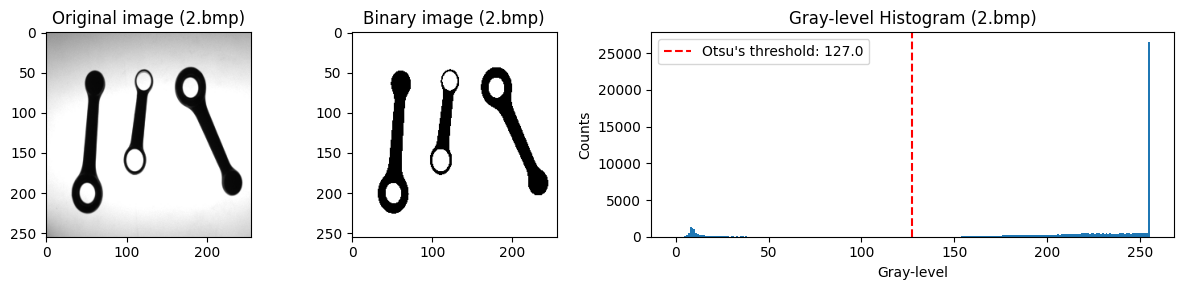

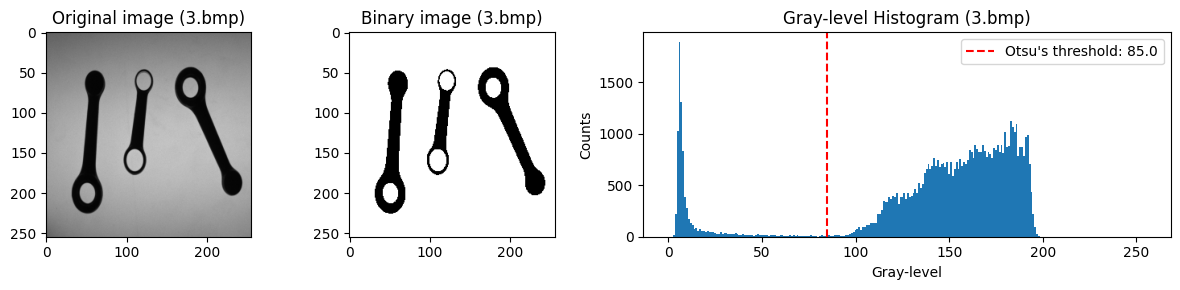

In [759]:
import plotter
importlib.reload(plotter) # Be sure to load the latest version of our "parameters.py" module (useful in Jupyter Notebook)
indices = [1, 2] # Indexes to be used only for visualization purposes within this Jupyter Notebook file
plotter.plotBinarizationResults(indices, imagesNames, images, binaryImages, histograms, otsuThresholds)


### Connected Components Labeling

Due to the simplifying assumptions of this [First Task](#first-task), we assume that in each obtained binary image **all** the connected components (alias BLOBs) correspond to distinct connecting-rods, without exceptions (all of that will be tackled in a more careful way in the [Second Task](#second-task)). That said, connected components (labelled and with [some statistics](https://docs.opencv.org/3.4/d3/dc0/group__imgproc__shape.html#gac7099124c0390051c6970a987e7dc5c5)) can be obtained from the binary images thanks to the method [`cv2.connectedComponentsWithStats`](https://docs.opencv.org/3.4/d3/dc0/group__imgproc__shape.html#ga107a78bf7cd25dec05fb4dfc5c9e765f). Two important keypoints:
- 8-way connectivity will be adopted (to ensure a conservative definition of connected components *and thereby reducing the risk of artificial gaps in the end-rings*).
- `cv2.connectedComponentsWithStats` (as well as [`cv2.findContours`](https://docs.opencv.org/4.x/d3/dc0/group__imgproc__shape.html#gadf1ad6a0b82947fa1fe3c3d497f260e0) and morphological operators implemented in OpenCV) assumes background pixels (BKG) to be coded as 0 and foreground pixels (FRG) to be coded as non-zero values. For this reason, a [`cv2.bitwise_not`](https://docs.opencv.org/4.x/d2/de8/group__core__array.html?utm_source=chatgpt.com#ga0002cf8b418479f4cb49a75442baee2f) operation must be applied *before* processing the previously obtained binary images.

The following code extracts BLOBs from binary images. Furthermore, for each BLOB, its ROI is extracted from its original binary image. The ROI is defined as the BLOB’s image-axis-aligned Bounding Box. Important: within each ROI, all pixels that ***are not*** part of the related BLOB are set to 0 **and** all pixels that ***are*** part of the related BLOB are set to 255 (which is coherent with the previously stated convention of `cv2.connectedComponentsWithStats`). Notice that `cv2.connectedComponentsWithStats` also returns BLOBs centroids (alias barycenters).

In [760]:
from miscellaneous import Connectivity
from detectorCRods import CRodBLOB
BLOBs = []
for index, binaryImage in enumerate(binaryImages):
    labels, labelledImage, stats, centroids = cv2.connectedComponentsWithStats(cv2.bitwise_not(binaryImage), connectivity = Connectivity.EIGHT_CONNECTIVITY.value)
    for label in range(1, labels): # Be aware: we are starting from 1 to skip the background label (labelled as 0)
        STAT_LEFT, STAT_TOP, STAT_WIDTH, STAT_HEIGHT, STAT_AREA = stats[label]
        ROI = labelledImage[STAT_TOP:STAT_TOP+STAT_HEIGHT, STAT_LEFT:STAT_LEFT+STAT_WIDTH].copy()
        ROI[ROI != label] = 0 # Getting rid of other BLOBs
        BLOB = CRodBLOB(
            imageName = imagesNames[index],
            label = label,
            STAT_LEFT = STAT_LEFT,
            STAT_TOP = STAT_TOP,
            STAT_AREA = STAT_AREA,
            ROI = ((ROI != 0).astype(np.uint8))*255, # Setting 0 value for BKG pixels and 255 value for FRG/BLOB pixels
            centroid = tuple(centroids[label])
        )
        BLOBs.append(BLOB)
# Notice: from "empty" images, no BLOBs will be extracted

The obtained results are the various BLOBs extracted from the binary images correctly labeled (as expected), for example:

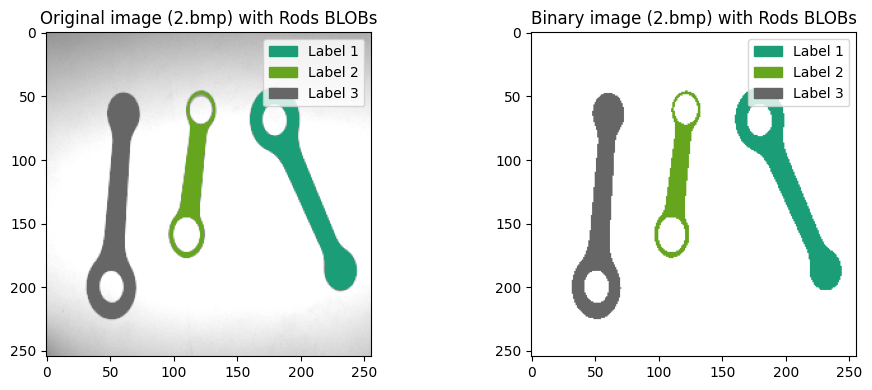

In [761]:
index = 1 # Index to be used only for visualization purposes within this Jupyter Notebook file
plotter.plotImageConnectedComponents(images[index], binaryImages[index], [b for b in BLOBs if b.imageName == imagesNames[index]])

Notice that we have done so far is a segmentation process, consisting of a series of binarization and labeling operations.

### BLOBs enhancement: getting rid of spurious internal contours

As will be stated, discussed and shown in a more detailed way throughout the following sections of the project, is important to highlight that *the notion of BLOB contours (both internal and external) will be ***fundamental*** to meeting all the required specifications* (where by internal contours we mean the contours of all the holes within the BLOB). Therefore, particular attention will be devoted to defining a processing pipeline (from the initial raw working images to the final expected result produced by the software) that carefully extracts and properly refines and "tames" both internal and external contours.

In particular, the internal contours of each BLOB will play a crucial role in detecting the holes within the BLOB itself. For a BLOB representing a single isolated connecting-rod, once properly processed, we expect *exactly* one internal contour for each one of its actual holes of the connecting-rod itself. Consequently, there should be *exactly* one or two internal contours (corresponding to TypeA or TypeB connecting-rods, respectively).

Although this assumption is consistent with the technique used to acquire the raw working images (alias backlighting technique), the BLOBs produced by the (simple) processing pipeline implemented so far do not necessarily satisfy it. In fact, some BLOBs exhibit spurious internal contours (alias, spurious holes) that are not related to actual holes: they are artifacts arised from FRG pixels that have been mistakenly classified as BKG ones.<br>The following image highlights the problem (affecting the upper connected-rod in its upper end-ring):

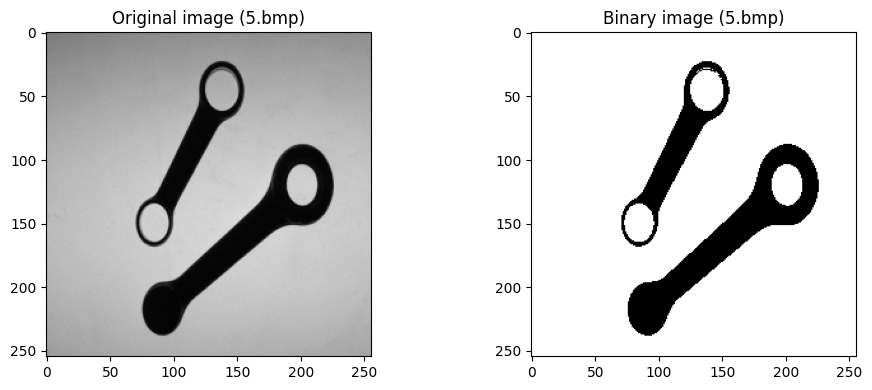

In [762]:
indices = [4] # Indexes to be used only for visualization purposes within this Jupyter Notebook file
plotter.plotBinarizationResults(indices, imagesNames, images, binaryImages)

This is an issue that needs to be tackled. The main cause of this issue is attributed to the possible presence (in the original raw working images) of small shadows, reflections, or lighting artifacts (for example, ones within the inner regions of the holes/end-rings of the connecting-rods, as shown in the last image).

As a consequence, it is reasonably assumed that the spurious holes (to get rid of) have a significantly smaller area and (especially) are considerably thinner (in their shape) than the actual holes. More precisely, it's assumed that, if each hole is treated as a connected component on its own, a simple erosion with a full-ones 3×3 structuring element will completely eliminate it IFF it's a spurious one. In line with this assumption, the following sequence of operations is implemented in the subsequent code (applied to each BLOB obtained so far):
- Extraction of external and internal contours.
- Each internal contour is drawn onto a separate small binary image.
- On this small binary image, a flood-fill operation of the BKG is performed.
- A bitwise NOT operation is then applied to the resulting image, thus obtaining the BLOB corresponding to the hole identified by the internal contour under analysis.
- A morphological erosion with a full-ones 3×3 structuring element is applied.
- If, after erosion, the BLOB is completely removed, the corresponding hole (and its internal contour) is considered spurious; otherwise, it is regarded as an actual one.

Before proceeding with the said code, three important keypoints about contours extraction, flood-filling and erosion:
- Contours extraction can be performed in a straightforward and efficient way by exploiting the concept of connectivity and the fact that we are dealing with binary images, rather than grayscale ones (indeed, with connected components). In this regard, the OpenCV library provides the dedicated method [`cv2.findContours`](https://docs.opencv.org/4.x/d3/dc0/group__imgproc__shape.html#gadf1ad6a0b82947fa1fe3c3d497f260e0), which also separately returns the external contour and internal contours. It is worth noting that the `cv2.findContours` method relies on 8-way connectivity (which is consistent with our previous choice of adopting 8-way connectivity for BLOBs/FRG extraction during the segmentation process) and returns [contour] points that *exclusively* belong to the BLOB.<br>Additionally, [RetrievalModes](https://docs.opencv.org/4.x/d3/dc0/group__imgproc__shape.html#ga819779b9857cc2f8601e6526a3a5bc71) and [ContourApproximationModes](https://docs.opencv.org/4.x/d3/dc0/group__imgproc__shape.html#ga4303f45752694956374734a03c54d5ff) of this method can be explored in the official related documentation. We will also stick to the following good practice: to improve the robustness of `cv2.findContours`, it is good practice to apply a one-pixel BKG padding (to prevent BLOBs from touching image borders) before executing `cv2.findContours` itself.
- 4-way connectivity will be adopted for the flood-filling operation of the BKG (since 8-way connectivity has indeed been adopted for the BLOBs/FRG). To perform that flood-filling operation, the OpenCV library provides the dedicated method [`cv2.floodFill`](https://docs.opencv.org/4.x/d7/d1b/group__imgproc__misc.html#ga366aae45a6c1289b341d140839f18717). The flood-fill operation will be performed starting from the top-left pixel. In this sense, a one-pixel BKG padding before the flood-filling operation itself will be carried out to ensure that the top-left pixel will be a BKG one and will be connected to the entire BKG region we aim to fill.
- Erosion can be performed through the dedicated OpenCV method [`cv2.erode`](https://docs.opencv.org/4.x/d4/d86/group__imgproc__filter.html#gaeb1e0c1033e3f6b891a25d0511362aeb).

BLOB (label: 1, image name: 5.bmp): detected 5 spurious internal contours (and 2 actual ones).


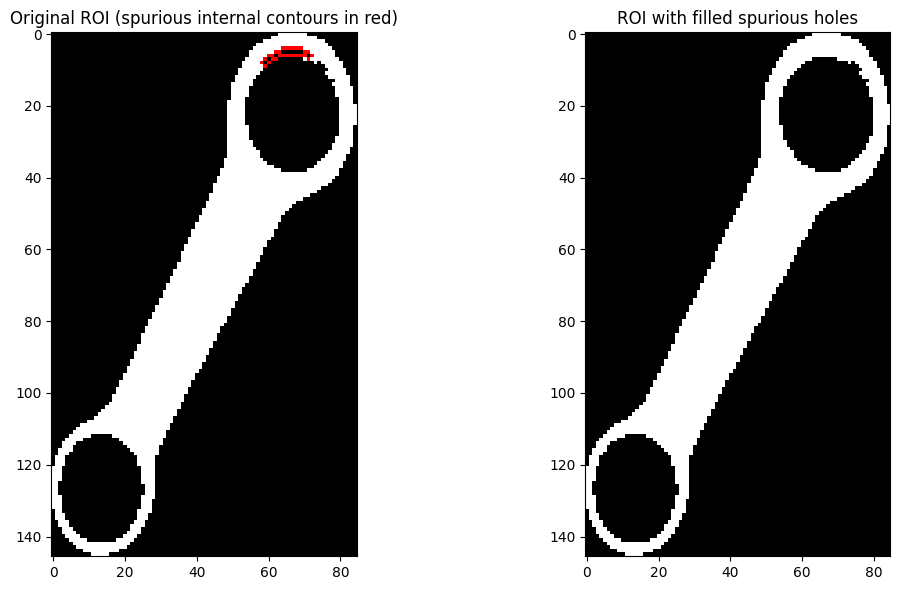

Notice: for all remaining BLOBs (if any), no spurious internal contours detected.


In [763]:
def blobEnhancementStep(BLOBs, logging = True):
    for BLOB in BLOBs:
        ROI = BLOB.ROI.copy()
        h, w = ROI.shape
        ROIPADDING = 1
        paddedROI = np.zeros((h + 2*ROIPADDING, w + 2*ROIPADDING), dtype=ROI.dtype)
        paddedROI[ROIPADDING:ROIPADDING+h, ROIPADDING:ROIPADDING+w] = ROI
        contours, hierarchy = cv2.findContours(
            paddedROI,            # binary image from which extract contours (0 as BKG, non-zero as FRG)
            cv2.RETR_CCOMP,       # A Retrieval Mode that makes retrieved contours organized in externals and internals ones.
                                # In this Retrival Mode, hierarchy[0][i][3] (that always contains the index of the parent contour) is -1 IFF the contour is an external one.
                                # (notice: the 0 index is necessary in relation to how the returned "hierarchy" variable is structured)
            cv2.CHAIN_APPROX_NONE # A Contour Approximation Mode that makes sure to retrive ALL the points of the contours
        )
        externalContours = [contours[i] for i in range(len(contours)) if hierarchy[0][i][3] == -1] # list of int32 els. of shape (N, 1, 2) (the "1" dimension is a "fictitious" one, related to how contours are structured in Python OpenCV)
        internalContours = [contours[i] for i in range(len(contours)) if hierarchy[0][i][3] != -1] # list of int32 els. of shape (N, 1, 2) (the "1" dimension is a "fictitious" one, related to how contours are structured in Python OpenCV)
        if len(externalContours) != 1: raise RuntimeError(f'Unexpected number of external contours for a BLOB (image name: {BLOB.imageName}, label: {BLOB.label}). Expected exactly 1, got {len(externalContours)}')
        externalContour = externalContours[0]
        offset = np.array([[[int(BLOB.STAT_LEFT - ROIPADDING), int(BLOB.STAT_TOP - ROIPADDING)]]], dtype = externalContour.dtype)
        # Notice about the offset: the single contour has shape (N, 1, 2). Indeed, dealing on broadcasting, it can be summed to an array of shape (1, 1, 2) to get an element-wise sum
        BLOB.externalContour = (externalContour + offset).reshape(-1, 2) # Passing from shape (N, 1, 2) to shape (N, 2), intended as a collection of (x,y) points
        validInternalContours = []
        invalidInternalContours = []
        for internalContour in internalContours:
            # Retrive an image-axis-aligned Bounding Box (minimum BB that contains ALL contour points) (we might use https://docs.opencv.org/4.x/d3/dc0/group__imgproc__shape.html#ga103fcbda2f540f3ef1c042d6a9b35ac7)
            x, y, w, h = cv2.boundingRect(internalContour)
            # x, xMax = np.min(internalContour[:, 0, 0]), np.max(internalContour[:, 0, 0])
            # y, yMax = np.min(internalContour[:, 0, 1]), np.max(internalContour[:, 0, 1])
            # w, h = xMax-x+1, yMax-y+1
            smallROIPADDING = 1
            smallROI = np.zeros((h + 2*smallROIPADDING, w + 2*smallROIPADDING), dtype=np.uint8)
            localInternalContour = internalContour.copy()
            localInternalContour[:, 0, 0] = localInternalContour[:, 0, 0]-x+smallROIPADDING # Referring contour to smallROI
            localInternalContour[:, 0, 1] = localInternalContour[:, 0, 1]-y+smallROIPADDING # Referring contour to smallROI
            contourPoints = localInternalContour.reshape(-1, 2) # Passing from shape (N, 1, 2) to shape (N, 2), intended as a collection of (x,y) points
            smallROI[contourPoints[:,1], contourPoints[:,0]] = 255 # Drawing contour (recall that images are indexed as [y,x])
            floodFillMask = np.zeros((smallROI.shape[0] + 2, smallROI.shape[1] + 2), dtype=np.uint8) # Required as indicated by cv2.floodFill documentation
            cv2.floodFill(
                image = smallROI,                            # Input/Output image (in-place modification)
                mask = floodFillMask,                        # Mask image (see cv2.floodFill documentation for details)
                seedPoint = (0, 0),                          # Starting point for the flood fill algorithm
                newVal = 255,                                # Value to be assigned to the repainted pixels
                flags = Connectivity.FOUR_CONNECTIVITY.value # Connectivity for the flood fill algorithm
            )
            holeBlob = cv2.bitwise_not(smallROI)
            structuringElement = parameters.structuringElement
            erodedHoleBlob = cv2.erode(
                src = holeBlob,                   # Input image to be eroded                                      
                kernel = structuringElement,      # Structuring element to be used for the erosion
                iterations = 1,                   # Number of successive erosions to be applied
                borderType = cv2.BORDER_CONSTANT, # Explicitindication to use a constant border (outside the image)
                borderValue = 0                   # Value of the said constant border (0 as BKG according to our convention)
            )
            if cv2.countNonZero(erodedHoleBlob) != 0:
                validInternalContours.append(internalContour)
            else:
                invalidInternalContours.append(internalContour)
                # holeBlob is referred as smallROI
                # smallROI is referred (AFTER a padding of smallROIPADDING) as the BB (with (x, y) top-left corner)
                # (x,y) is referred (as well as the contours) to the padded (with PADDING) ROI (retrieved from BLOB.ROI)
                xOffset = -smallROIPADDING+x-ROIPADDING
                yOffset = -smallROIPADDING+y-ROIPADDING
                ysHoleBlob, xsHoleBlob = np.where(holeBlob != 0)
                ROI[yOffset+ysHoleBlob, xOffset+xsHoleBlob] = 255 # Filling the spurious hole in the original ROI
        BLOB.internalContours = [(intContour + offset).reshape(-1, 2) for intContour in validInternalContours]
        if len(invalidInternalContours) > 0:
            # Upadting centroid/barycenter and area of the BLOB (to be done only if at least one spurious internal contour has been detected and will be consequently filled)
            yCoords, xCoords = np.where(ROI != 0)
            xCentroid = xCoords.mean() + BLOB.STAT_LEFT
            yCentroid = yCoords.mean() + BLOB.STAT_TOP
            BLOB.centroid = (xCentroid, yCentroid)
            BLOB.STAT_AREA = np.int32(yCoords.size)
            # Outputting and plotting some infos and results (only for visualization purposes within this Jupyter Notebook file)
            if logging:
                print(f"BLOB (label: {BLOB.label}, image name: {BLOB.imageName}): detected {len(invalidInternalContours)} spurious internal contours (and {len(validInternalContours)} actual ones).")
                invalidInternalContoursReferredToROI = [intContour - np.array([[[ROIPADDING, ROIPADDING]]], dtype=intContour.dtype) for intContour in invalidInternalContours] # Only for viualization purposes (to refer contours to the original ROI)
                plotter.plotSpuriousHolesFilled(BLOB.ROI, ROI, invalidInternalContoursReferredToROI)
        BLOB.ROI = ROI
    if logging: print("Notice: for all remaining BLOBs (if any), no spurious internal contours detected.")

blobEnhancementStep(BLOBs)

The image shown above illustrates the results of the previously described sequence of operations (implemented indeed to remove any possibly present spurious internal contour, alias spurious hole, within the single BLOB). In light of the procedure just performed, it will be assumed in the subsequent steps of the software pipeline that BLOBs **do** ***not*** contain any spurious internal contours  (alias spurious holes).

Before proceeding, two keypoints to be highlighted:
- *Why not use a closing?*<br>
As can be easily understood, applying a morphological closing operation to the whole BLOB (with a properly chosen structuring element) could have effectively solved the problem (of little spurious holes), without excessively altering or degrading its contours (on the contrary, it might even have enhanced the contours of a BLOB related to a single connecting-rod, potentially making them smoother and less irregular).<br>
However, closing was deliberately avoided with the [**Second Task**](#second-task) (and its more complex scenario) in mind. Indeed, for example, in the case of two connecting-rods in contact (a single contact), the raw BLOB obtained after segmentation (alias binarization and labeling) would consist of a single connected region, to be properly analyzed and *separated* into two distinct BLOBs (one for each actual connecting-rod). In such a scenario, performing a closing operation is to be avoided, since it may enlarge the one BLOB sub-region corresponding to the contact zone between connecting-rods (also reducing the *curvature* of contours in that region), which would make the said subsequent *separation* step more difficult to be done.
- *Why not use a Gaussian filter?*<br>
It may be noted that applying a [light] filtering step (for instance, using a Gaussian filter rather than a Mean one, in order to be less aggressive on objects contours) to the original grayscale image (alias *prior* to segmentation), might help getting rid of the already-mentioned spurious holes (in the BLOBs obtained *after* segmentation), already at an early stage.<br>
This aspect will be addressed and discussed in further details in Part A of the Second Task.

### BLOBs Analysis and Features Extraction

The final part of this [**First Task**](#first-task) focuses on analyzing the obtained BLOBs (which, as previously stated, are assumed to all represent connecting-rods **and** to contain no spurious internal contours) and on extracting of the required features.

The following list summarizes the methods adopted to extract each feature:
- **Connecting-rod type (A or B)**: easily determined by counting the number of internal contours (alias holes) within the BLOB.
- **Connecting-rod position**: the position is intended as the centroid/barycenter of the BLOB, which as been already computed.
- **Connecting-rod orientation**: the orientation is intended as the direction of maximum variation of the BLOB. It is given by the dominant eigenvector of the covariance matrix (positive semidefinite by definition) computed over the BLOB pixels/points (the dominant eigenvector is the one associated with the larger of the two eigenvalues).
- **Connecting-rod length**: computed as the difference between the maximum and minimum [among the] projections of the BLOB external contour points onto the BLOB orientation direction.
- **Connecting-rod width**: computed as the difference between the maximum and minimum [among the] projections of the external contour points (of the BLOB) onto the direction normal to the BLOB orientation.
- **Connecting-rod width at the barycenter**: defined as the length of the segment obtained by intersecting the BLOB with a line passing through its centroid and orthogonal to its orientation direction. In practical terms, the width at the barycenter is obtained through the following steps:<br>
(a) define an empty binary image with the same size as the ROI (of the BLOB under analysis).<br>
(b) compute L as half the ROI diagonal length.<br>
(c) define two [distinct] points at distance L from the BLOB barycenter along the direction normal to its orientation.<br>
(d) draw the line segment between these two points (using OpenCV’s [`cv2.line`](https://docs.opencv.org/4.x/d6/d6e/group__imgproc__draw.html#ga7078a9fae8c7e7d13d24dac2520ae4a2)) on the previously defined empty binary image.<br>
(e) identify the intersection points between the line and the BLOB by applying [`cv2.bitwise_and`](https://docs.opencv.org/4.x/d2/de8/group__core__array.html#ga60b4d04b251ba5eb1392c34425497e14) to the generated line image and the ROI.<br>
(f) project the intersection points onto the direction normal to the BLOB orientation.<br>
(g) define the width at the barycenter as the difference between the maximum and minimum of these projections.<br>
- **Center position of each [circular] hole**: for each hole, its position is computed by first retrieving the BLOB corresponding to that hole (using the same procedure previously adopted to discriminate spurious holes from real ones) and then computing its centroid.
- **Diameter of each [circular] hole**: for each hole, the corresponding BLOB is retrieved again and its area A is computed. The hole diameter is then obtained using $D=2\sqrt{A/\pi}$ (this measure is quite robust to contour-noise and invariant to rotation).

Before proceeding with the said code, a note: all together with the features listed above, each BLOB is also enriched with the notion of the center of the Bounding Box (BB) which encloses the BLOB and whose two sides are aligned with the BLOB orientation (as computed above) and with the direction orthogonal to it. *This is useful for visualization purposes*.

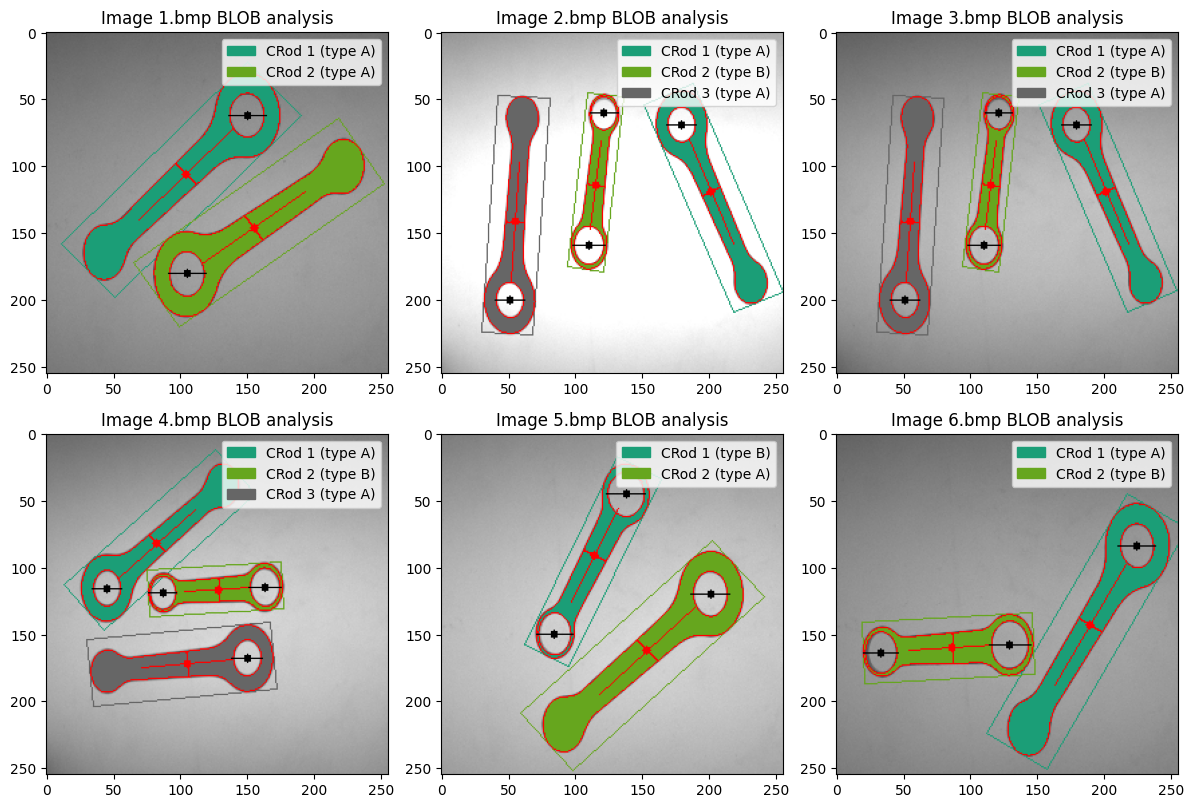

In [764]:
from miscellaneous import RodType

for BLOB in BLOBs:
    # Connecting-rod type (A or B)
    if len(BLOB.internalContours) == 1: BLOB.type = RodType.A
    elif len(BLOB.internalContours) == 2: BLOB.type = RodType.B
    else: raise RuntimeError(f'Unexpected number of internal contours for a BLOB that was interpreted as a connecting-rod (image name: {BLOB.imageName}, label: {BLOB.label}). Expected 1 or 2, got {len(BLOB.internalContours)}')
    # Connecting-rod position: it as been already computed (BLOB centroid)
    # Connecting-rod orientation (in the interval [0, pi) rad)
    yCoords, xCoords = np.where(BLOB.ROI != 0)
    _, eigenvectors = miscellaneous.computeCovariance2D(np.column_stack((xCoords, yCoords)))
    dominantEigenvector = eigenvectors[:, 1]
    nonDominantEigenvector = eigenvectors[:, 0]
    theta = np.arctan2(dominantEigenvector[1], dominantEigenvector[0])
    BLOB.orientationModuloPI = theta % np.pi
    # Connecting-rod length and width
    externalContourPoints = BLOB.externalContour - np.array([BLOB.STAT_LEFT, BLOB.STAT_TOP]) # Referring contour points to ROI (instead of original image)
    projectionsH = externalContourPoints @ dominantEigenvector
    projectionsW = externalContourPoints @ nonDominantEigenvector
    projsHmin, projsHmax, projsWmin, projsWmax = projectionsH.min(), projectionsH.max(), projectionsW.min(), projectionsW.max()
    BLOB.length = float(projsHmax-projsHmin)
    BLOB.width = float(projsWmax-projsWmin)
    centerBB = 0.5*(projsHmin+projsHmax)*dominantEigenvector + 0.5*(projsWmin+projsWmax) * nonDominantEigenvector # Referred to ROI
    BLOB.centerBB = BLOB.merCenter = (float(centerBB[0] + BLOB.STAT_LEFT), float(centerBB[1] + BLOB.STAT_TOP)) # Referring BB center to the original image
    # Connecting-rod width at the barycenter
    bXROI = BLOB.centroid[0] - BLOB.STAT_LEFT # Referring centroid coords to ROI (instead of original image)
    bYROI = BLOB.centroid[1] - BLOB.STAT_TOP  # Referring centroid coords to ROI (instead of original image)
    L = 0.5*np.sqrt(BLOB.ROI.shape[0]**2 + BLOB.ROI.shape[1]**2) # Half of the length of the diagonal of the ROI
    linePoint1 = (bXROI + L*nonDominantEigenvector[0], bYROI + L*nonDominantEigenvector[1])
    linePoint2 = (bXROI - L*nonDominantEigenvector[0], bYROI - L*nonDominantEigenvector[1])
    lineROI = np.zeros_like(BLOB.ROI, dtype = BLOB.ROI.dtype)
    cv2.line(# https://docs.opencv.org/4.x/d6/d6e/group__imgproc__draw.html#ga7078a9fae8c7e7d13d24dac2520ae4a2
        lineROI,                                                # Image onto which draw the line
        (int(round(linePoint1[0])), int(round(linePoint1[1]))), # Line starting point (needed an int value)
        (int(round(linePoint2[0])), int(round(linePoint2[1]))), # Line ending point (needed an int value)
        color = 255,                                            # Line color (retrieve the non-zero value of the ROI)
        thickness = 1,                                          # Line thickness (in pixels)
        lineType = cv2.LINE_8                                   # Line connectivity (4-way or 8-way)
    )
    commonPointsImage = cv2.bitwise_and(lineROI, BLOB.ROI) # https://docs.opencv.org/4.x/d2/de8/group__core__array.html#ga60b4d04b251ba5eb1392c34425497e14
    yCoords, xCoords = np.where(commonPointsImage != 0)
    if yCoords.size < 2: raise RuntimeError(f"Unexpected number of pixels/points obtained from the intersection between a connecting-rod BLOB and a line passing through its centroid and orthogonal to its orientation direction (image name: {BLOB.imageName}, label: {BLOB.label}). Expected at least 2, got {yCoords.size}")
    commonPoints = np.column_stack((xCoords, yCoords))
    intersectionPointsProjections = commonPoints @ nonDominantEigenvector
    # minimumIndex, maximumIndex = np.argmin(intersectionPointsProjections), np.argmax(intersectionPointsProjections) # Retriving indexes of minimum and maximum projections
    # extreme1 = commonPoints[minimumIndex]
    # extreme2 = commonPoints[maximumIndex]
    # BLOB.widthAtBarycenter = np.linalg.norm(extreme2-extreme1)
    BLOB.widthAtBarycenter = float(intersectionPointsProjections.max() - intersectionPointsProjections.min())
    # Center position and diameter of each [circular] hole (recycling previous code)(contours are now with shape (N,2))
    BLOB.holesCenters = []
    BLOB.holesDiameters = []
    for internalContour in BLOB.internalContours:
        x, y, w, h = cv2.boundingRect(internalContour.astype(np.int32))
        smallROIPADDING = 1
        smallROI = np.zeros((h + 2*smallROIPADDING, w + 2*smallROIPADDING), dtype=np.uint8)
        localInternalContour = internalContour.copy()
        localInternalContour[:, 0] = localInternalContour[:, 0]-x+smallROIPADDING # Referring contour to smallROI
        localInternalContour[:, 1] = localInternalContour[:, 1]-y+smallROIPADDING # Referring contour to smallROI
        smallROI[localInternalContour[:,1], localInternalContour[:,0]] = 255 # Drawing contour (recall that images are indexed as [y,x])
        floodFillMask = np.zeros((smallROI.shape[0] + 2, smallROI.shape[1] + 2), dtype=np.uint8) # Required as indicated by cv2.floodFill documentation
        cv2.floodFill(
            image = smallROI,                            # Input/Output image (in-place modification)
            mask = floodFillMask,                        # Mask image (see cv2.floodFill documentation for details)
            seedPoint = (0, 0),                          # Starting point for the flood fill algorithm
            newVal = 255,                                # Value to be assigned to the repainted pixels
            flags = Connectivity.FOUR_CONNECTIVITY.value # Connectivity for the flood fill algorithm
        )
        holeBlob = cv2.bitwise_not(smallROI)
        yCoords, xCoords = np.where(holeBlob != 0)
        yCentroid, xCentroid = yCoords.mean(), xCoords.mean() # Centroid coords referred to smallROI
        BLOB.holesCenters.append((
            xCentroid+x-smallROIPADDING, # Referring centroid coords to the original image
            yCentroid+y-smallROIPADDING  # Referring centroid coords to the original image
        ))
        A = yCoords.size
        BLOB.holesDiameters.append(2*np.sqrt(A/np.pi))

plotter.plotBLOBAnalysis(imagesNames, images, BLOBs)

With that, the First Task is complete. Images (shown above) illustrate the obtained results by highlighting the extracted features.


<a id="second-task"></a>
## Second Task

As previously anticipated, the [**Second Task**](#second-task) considers a less simple scenario and upgrades the already developed software accordingly. Consistently with their nature, the changes in the characteristics of the working images (which may also occur simultaneously within the same image) will be addressed in the following order:<br>
(A) inspection area may be dirty due to the presence of scattered iron powder<br>
(B) images may contain distractors (to be ignored)<br>
(C) connecting rods *(and only them)* may be in contact with each other (without overlapping *and without touching distractors*)<br>

### (A) Dealing with dirty inspection areas

The first change (in the characteristics of the working images) that will be addressed is the possibility of having a dirty inspection area. The images below highlight how the pipeline implemented so far behaves in this scenario, specifically showing only the binary images obtained after the segmentation step (binarization and labeling):


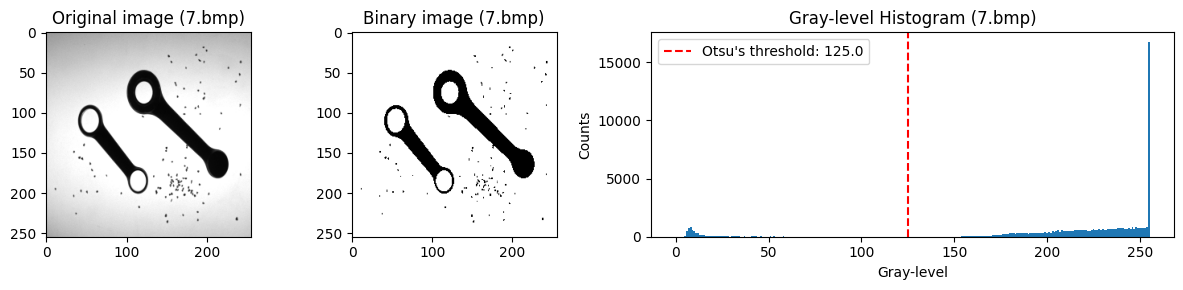

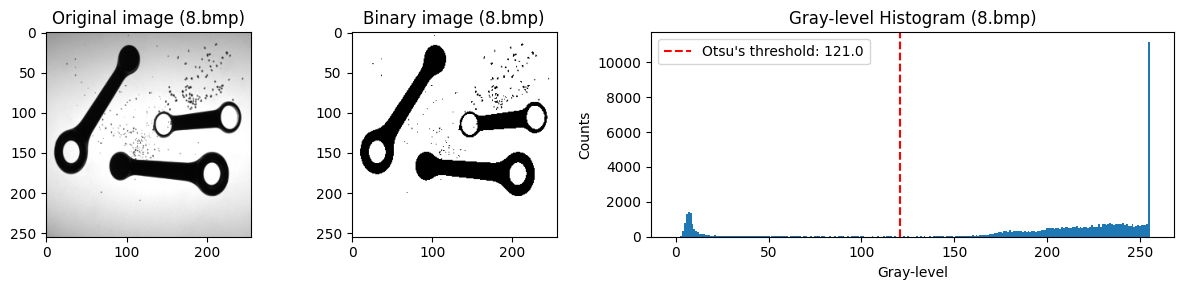

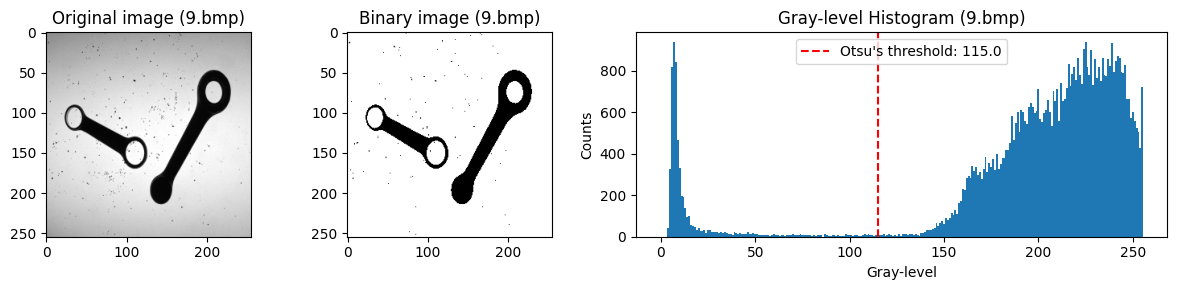

In [765]:
imagesNames, images = miscellaneous.loadImages(miscellaneous.Task.SECOND_TASK)
indices = [6, 7, 8] # Indexes to be used only for visualization purposes within this Jupyter Notebook file
iNames = [imagesNames[i] for i in indices]
imgs = [images[i] for i in indices]
bImgs, histograms, otsuThresholds = binarizationStep(imgs)
plotter.plotBinarizationResults([0, 1, 2], iNames, imgs, bImgs, histograms, otsuThresholds)

The above images, and more generally the type of change/issue that we are now addressing (change A), provide an opportunity to highlight a phase that is often included in Industrial Vision workflows (i.e., CV applied in industrial frameworks) when relying on segmentation: performing a filtering step before segmentation itself (IFF it is actually needed and properly motivated).

Indeed, from this point onward, the upgraded processing pipeline of the [**Second Task**](#second-task) will include a 3×3 kernel Gaussian Filtering step before segmentation (with the variance automatically selected, based on the kernel size, by OpenCV’s [`cv2.GaussianBlur`](https://docs.opencv.org/4.x/d4/d86/group__imgproc__filter.html#gae8bdcd9154ed5ca3cbc1766d960f45c1) method). This choice is related to the following points:
- Using a filter is in general beneficial in the presence of noise in the raw working images (images that may not be as ideal as assumed in the [First Task](#first-task)) *and* in the application under analysis it will alter the images into new ones that are more suitable for extracting information/features from in a robust way.
- As previously introduced, the notion of BLOB contours (both internal and external) is considered fundamental to meeting all the required specifications. In this regard, a dirty inspection area (with larger or smaller scattered powder particles) may lead to spurious (i.e., non-actual) deformations of the BLOBs internal/external contours shapes extracted after segmentation. In particular, it can affect their curvature, also generating *artifactual* local regions where contour points accumulate, *even when* (referring to the same region in the actual image) they should instead be mostly aligned along a main direction (as shown in the following images). **This is an issue that needs to be tackled.** In this respect, the aforementioned Gaussian filtering step has proven effective.
- Moreover, recalling what was already done in the [First Task for getting rid of spurious internal contours/holes](#blobs-enhancement-getting-rid-of-spurious-internal-contours), adding a Gaussian Filter prior to segmentation helps with getting rid of them already from an early stage: it makes spurious internal contours (survived after segmentation) smaller, or even completely absent (and therefore already resolved). In this sense, the combined action of the procedure already implemented in the First Task **and** the newly introduced Gaussian filtering step is considered effective (in getting rid of spurious holes) even under more extreme lighting-artifact conditions than those observed in the raw working images under analysis for this project.
- Despite these above-mentioned beneficial effects, it is imperative (of course) that the Filter does not degrade the contours of objects in the image (it should make them smoother and less noisy, and less prone to artifactual curvatures, *but without* altering them topologically). This is especially important to keep the extracted BLOBs related to connecting-rods intact, and to avoid openings in their end-rings even when those rings are very thin. For this reason, a Gaussian filter is chosen (rather than, for example, a Mean filter), and the kernel size has to be selected as small as possible (while still being effective), based on our application.

Before proceeding, an important keypoint: among the motivations for presence of the said Gaussian filter, we **do not** include achieving the **total** absence of BLOBs (after segmentation) related to scattered powder particles. On the contrary, the presence of such particles among the extracted BLOBs will be tackled differently: given the particular application we are dealing with, assuming that these particles are **not** actual objects (neither connecting-rods, nor distractors), and assuming that their corresponding BLOBs have a **much smaller area** than ones of actual objects, scattered-powder BLOBs will be eliminated simply by applying an area-based thresholding step. Of course, the area-threshold must be chosen based on the specific application, and with reference to a fixed, pre-selected size of the raw working images. In this project, we will use a value of 100.

The following code implements what has just been described, integrating it in the processing pipeline of the software.

In [766]:
# Images smoothing step (by means of a Gaussian Filter with a 3x3 kernel)(novelty)
images = [
    cv2.GaussianBlur(image, (parameters.gaussianFilterKernelSize, parameters.gaussianFilterKernelSize), 0) # variance sigma automatically set by OpenCV (based on the kernel size) as sigma=0.15*k+0.35=0.8+0.3*[(k-1)/2-1]
    for image in images
]

# Images binarization step (as already seen)
binaryImages, histograms, otsuThresholds = binarizationStep(images)

# Images labeling step (upgraded version, as described above)
BLOBs = []
for index, binaryImage in enumerate(binaryImages):
    labels, labelledImage, stats, centroids = cv2.connectedComponentsWithStats(cv2.bitwise_not(binaryImage), connectivity = Connectivity.EIGHT_CONNECTIVITY.value)
    for label in range(1, labels):
        STAT_LEFT, STAT_TOP, STAT_WIDTH, STAT_HEIGHT, STAT_AREA = stats[label]
        # ------------------- novelty --------------------
        if STAT_AREA <= parameters.areaThreshold: continue
        # ------------------------------------------------
        ROI = labelledImage[STAT_TOP:STAT_TOP+STAT_HEIGHT, STAT_LEFT:STAT_LEFT+STAT_WIDTH].copy()
        ROI[ROI != label] = 0 # Getting rid of other BLOBs
        BLOB = CRodBLOB(
            imageName = imagesNames[index],
            label = label,
            STAT_LEFT = STAT_LEFT,
            STAT_TOP = STAT_TOP,
            STAT_AREA = STAT_AREA,
            ROI = ((ROI != 0).astype(np.uint8))*255, # Setting 0 value for BKG pixels and 255 value for FRG/BLOB pixels
            centroid = tuple(centroids[label])
        )
        BLOBs.append(BLOB)

# Images enhancement step (as already seen)
blobEnhancementStep(BLOBs, logging=False)

The following image shows an example of the beneficial effects of the newly introduced Gaussian filtering step:

In [ ]:
oldIndex = 0 # Index to be used only for visualization purposes within this Jupyter Notebook file
newIndex = 6 # Index to be used only for visualization purposes within this Jupyter Notebook file
holes = 1 # Value to be used only for visualization purposes within this Jupyter Notebook file
exampleBLOB = ([b for b in BLOBs if b.imageName == imagesNames[newIndex] and len(b.internalContours) == holes])
xROI, yROI = int(exampleBLOB[0].STAT_LEFT), int(exampleBLOB[0].STAT_TOP)
hROI, wROI = exampleBLOB[0].ROI.shape
ROIbefore = bImgs[oldIndex][yROI:yROI+hROI, xROI:xROI+wROI]
ROIafter = binaryImages[newIndex][yROI:yROI+hROI, xROI:xROI+wROI]
print(ROIbefore.size)
print(ROIafter.size)
point  = (wROI // 2, hROI // 2)            # (x, y) in coordinate ROI
radius = max(3, min(hROI, wROI) // 6)
plotter.plotContoursEnhanced(ROIbefore, ROIafter, point, radius)

import matplotlib.pyplot as plt

plt.figure()
plt.plot([0, 1], [0, 1])
plt.title("test")
plt.show()


17010
17010


notare foto

foto zoom contorno lercio e migliorato

foto nuove con istogrammi per tutte le immagini (normal e binario)

foto prima e dopo aree tolte

nota finale: rimangon solo oggeto (rods o distrattori) as expected